In [ ]:
import os
import torch
import numpy as np

from torchvision import datasets, transforms
from torchvision.models import mobilenet_v3_large

from torch.utils.data import (
    DataLoader,
    random_split
)

from sklearn.utils.class_weight import compute_class_weight

import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import shutil
from tqdm import tqdm

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/Shareddrives/Dataset Padi_ML/archive (38)/rice'

DATASET_DIR = os.path.join(
    base_path,
    'classification_dataset_preprocessed'
)

In [ ]:
full_transform = transforms.Compose([

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
full_dataset = datasets.ImageFolder(
    DATASET_DIR,
    transform=full_transform
)

print("Class:")
print(full_dataset.classes)

Class:
['BacterialLeafBlight', 'BrownSpot', 'Healthy', 'LeafSmut', 'OtherDisease']


In [ ]:
# SPLIT TRAIN
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train size : {len(train_dataset)}")
print(f"Val size   : {len(val_dataset)}")


Train size : 14494
Val size   : 3624


In [ ]:
# DATALOADER
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [ ]:
# CLASS WEIGHTS
labels = full_dataset.targets

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)


In [ ]:
# DEVICE
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)

cuda


# Mobile Net

In [ ]:
# MODEL
model = mobilenet_v3_large(pretrained=True)

# ganti classifier
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    len(full_dataset.classes)
)

model = model.to(device)

# LOSS & OPTIMIZER
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 142MB/s]


In [ ]:
# TRAIN FUNCTION
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        acc = 100 * correct / total

        loop.set_postfix(
            loss=loss.item(),
            acc=acc
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


# VALIDATION FUNCTION
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [ ]:
NUM_EPOCHS = 15

best_val_acc = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # TRAIN
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    # VALIDATION
    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # SAVE HISTORY
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    # SAVE BEST MODEL
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            'best_mobilenetv3.pth'
        )

        print("Best model saved!")


Epoch 1/15


100%|██████████| 453/453 [44:29<00:00,  5.89s/it, acc=86.3, loss=0.0156]


Train Loss : 0.4375
Train Acc  : 86.26%
Val Loss   : 0.1018
Val Acc    : 96.11%
Best model saved!

Epoch 2/15


100%|██████████| 453/453 [01:50<00:00,  4.10it/s, acc=95.9, loss=0.16]


Train Loss : 0.1026
Train Acc  : 95.89%
Val Loss   : 0.0954
Val Acc    : 97.52%
Best model saved!

Epoch 3/15


...

Train Loss : 0.0335
Train Acc  : 98.78%
Val Loss   : 0.0200
Val Acc    : 98.84%

Epoch 14/15


100%|██████████| 453/453 [01:54<00:00,  3.94it/s, acc=99.3, loss=0.00477]


Train Loss : 0.0143
Train Acc  : 99.31%
Val Loss   : 0.0366
Val Acc    : 98.87%

Epoch 15/15


100%|██████████| 453/453 [01:53<00:00,  4.00it/s, acc=99.2, loss=0.00095]


Train Loss : 0.0224
Train Acc  : 99.20%
Val Loss   : 0.0335
Val Acc    : 98.43%


In [ ]:
shutil.copy(
    '/content/best_mobilenetv3.pth',
    '/content/drive/Shareddrives/Dataset Padi_ML/best_mobilenetv3.pth'
)

'/content/drive/Shareddrives/Dataset Padi_ML/best_mobilenetv3.pth'


CLASSIFICATION REPORT

                     precision    recall  f1-score   support

BacterialLeafBlight       0.96      1.00      0.98       310
          BrownSpot       1.00      0.99      1.00      2228
            Healthy       0.94      1.00      0.97        16
           LeafSmut       1.00      0.99      0.99      1051
       OtherDisease       0.61      1.00      0.76        19

           accuracy                           0.99      3624
          macro avg       0.90      1.00      0.94      3624
       weighted avg       0.99      0.99      0.99      3624



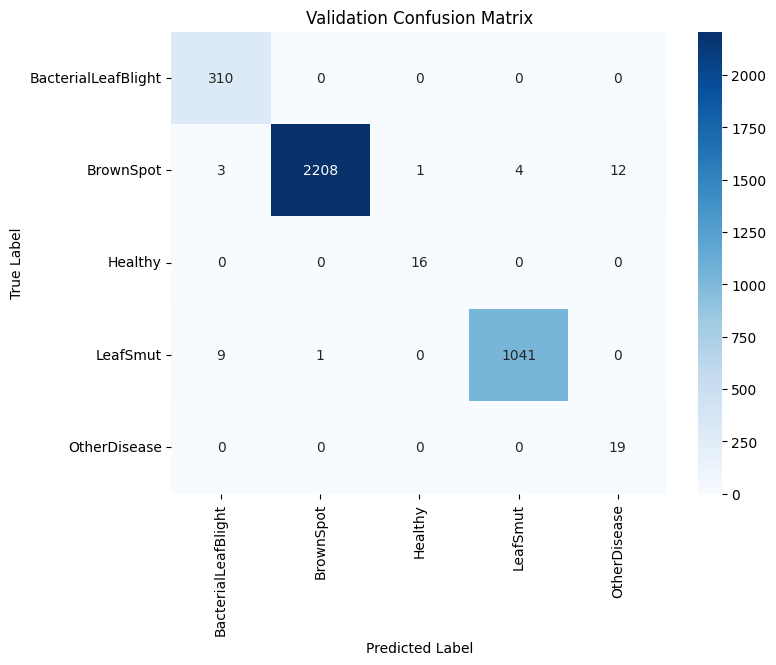

In [ ]:
# LOAD BEST MODEL
model.load_state_dict(
    torch.load('best_mobilenetv3.pth')
)

model.eval()

# PREDICTION
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# CLASSIFICATION REPORT
print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=full_dataset.classes
))

# CONFUSION MATRIX
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=full_dataset.classes,
    yticklabels=full_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Validation Confusion Matrix")

plt.show()

# Densenet

In [ ]:
from torchvision.models import densenet121

In [ ]:
model = densenet121(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 190MB/s]


In [ ]:
model.classifier = nn.Linear(
    model.classifier.in_features,
    len(full_dataset.classes)
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
torch.save(
    model.state_dict(),
    'best_densenet121.pth'
)

In [ ]:
model.load_state_dict(
    torch.load('best_densenet121.pth')
)

<All keys matched successfully>

In [ ]:
# DENSENET121 TRAINING

NUM_EPOCHS = 15

best_val_acc = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # TRAIN
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    # VALIDATION
    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # SAVE HISTORY
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # PRINT RESULT
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    # SAVE BEST MODEL
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            'best_densenet121.pth'
        )

        print("Best DenseNet121 model saved!")


Epoch 1/15


100%|██████████| 453/453 [02:37<00:00,  2.88it/s, acc=85.9, loss=0.0871]


Train Loss : 0.4101
Train Acc  : 85.90%
Val Loss   : 0.1577
Val Acc    : 93.38%
Best DenseNet121 model saved!

Epoch 2/15


100%|██████████| 453/453 [02:38<00:00,  2.86it/s, acc=95.4, loss=0.203]


Train Loss : 0.1295
Train Acc  : 95.43%
Val Loss   : 0.0593
Val Acc    : 97.68%
Best DenseNet121 model saved!

Epoch 3/15


...

Train Loss : 0.0469
Train Acc  : 98.08%
Val Loss   : 0.0279
Val Acc    : 98.92%

Epoch 14/15


100%|██████████| 453/453 [02:40<00:00,  2.82it/s, acc=98.5, loss=0.00258]


Train Loss : 0.0422
Train Acc  : 98.52%
Val Loss   : 0.1297
Val Acc    : 97.30%

Epoch 15/15


100%|██████████| 453/453 [02:40<00:00,  2.82it/s, acc=98.1, loss=0.0234]


Train Loss : 0.0470
Train Acc  : 98.13%
Val Loss   : 0.0370
Val Acc    : 98.12%


In [ ]:
shutil.copy(
    '/content/best_densenet121.pth',
    '/content/drive/Shareddrives/Dataset Padi_ML/best_densenet121.pth'
)

'/content/drive/Shareddrives/Dataset Padi_ML/best_densenet121.pth'


CLASSIFICATION REPORT

                     precision    recall  f1-score   support

BacterialLeafBlight       0.97      0.98      0.97       310
          BrownSpot       1.00      1.00      1.00      2228
            Healthy       1.00      1.00      1.00        16
           LeafSmut       0.99      0.99      0.99      1051
       OtherDisease       0.67      0.84      0.74        19

           accuracy                           0.99      3624
          macro avg       0.92      0.96      0.94      3624
       weighted avg       0.99      0.99      0.99      3624



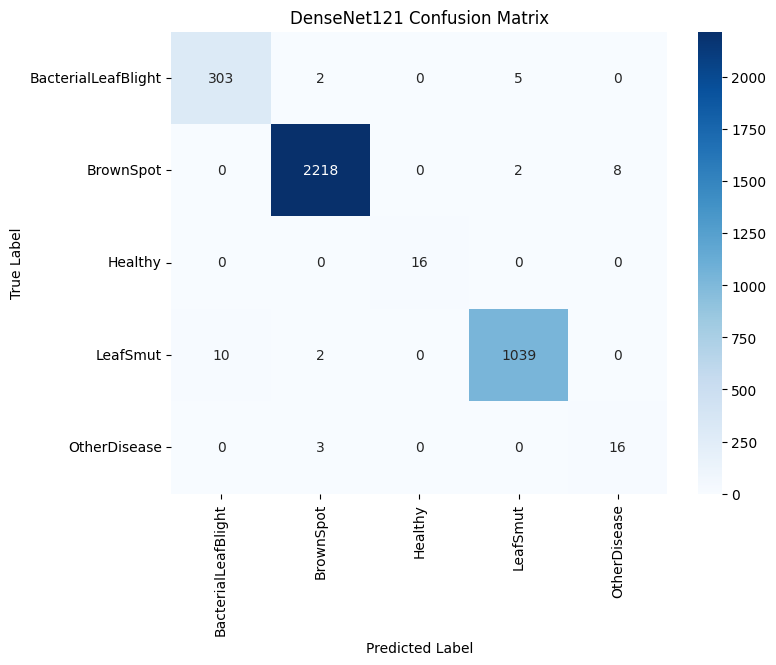

In [ ]:
# LOAD BEST DENSENET MODEL
model.load_state_dict(
    torch.load('best_densenet121.pth')
)

model.eval()

# PREDICTION
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# CLASSIFICATION REPORT
print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=full_dataset.classes
))

# CONFUSION MATRIX
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=full_dataset.classes,
    yticklabels=full_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("DenseNet121 Confusion Matrix")

plt.show()

# Eksternal Test Mobilenet

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
TEST_DIR = '/content/drive/Shareddrives/Dataset Padi_ML/archive (38)/test_prepro'

In [ ]:
test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print(test_dataset.classes)

['BacterialLeafBlight', 'BrownSpot', 'Healthy', 'LeafSmut', 'OtherDisease']


In [ ]:
from collections import Counter

counter = Counter(test_dataset.targets)

for idx, cls in enumerate(test_dataset.classes):
    print(f"{cls}: {counter[idx]}")

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

print(device)

cuda


In [ ]:
from torchvision.models import mobilenet_v3_large
import torch.nn as nn

model = mobilenet_v3_large(pretrained=False)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    5
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
model.load_state_dict(
    torch.load('/content/drive/Shareddrives/Dataset Padi_ML/best_mobilenetv3.pth')
)

model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
))

                     precision    recall  f1-score   support

BacterialLeafBlight       0.26      0.82      0.40       371
          BrownSpot       0.68      0.16      0.26       637
            Healthy       0.31      0.83      0.45       175
           LeafSmut       0.38      0.86      0.52        77
       OtherDisease       0.00      0.00      0.00       700

           accuracy                           0.31      1960
          macro avg       0.33      0.53      0.33      1960
       weighted avg       0.31      0.31      0.22      1960



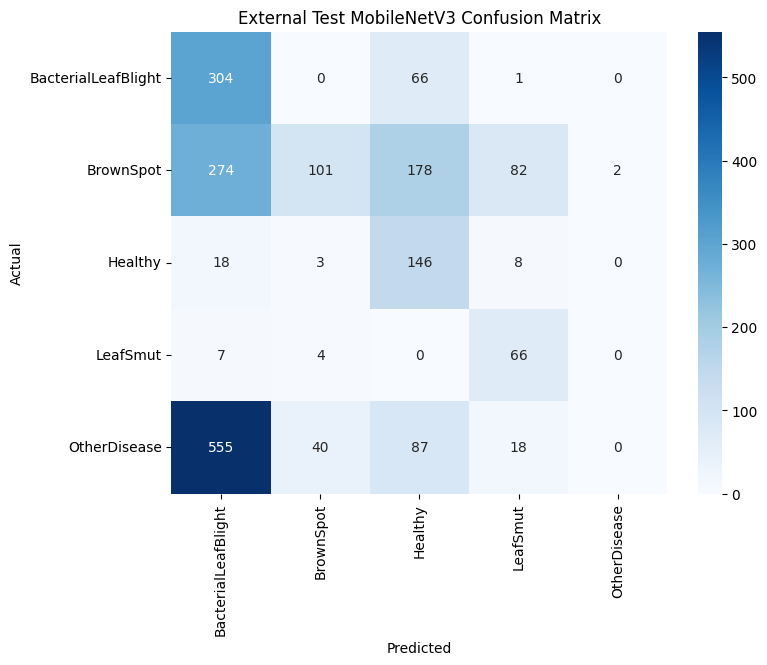

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_preds,
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("External Test MobileNetV3 Confusion Matrix")

plt.show()

# Eksternal Test Densenet

In [ ]:
from torchvision.models import densenet121
import torch.nn as nn

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

print(device)

cuda


In [ ]:
model = densenet121(pretrained=False)

model.classifier = nn.Linear(
    model.classifier.in_features,
    5
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
model.load_state_dict(
    torch.load(
        '/content/drive/Shareddrives/Dataset Padi_ML/best_densenet121.pth',
        map_location=device
    )
)

model.eval()

print("DenseNet121 loaded successfully")

DenseNet121 loaded successfully


In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
))

                     precision    recall  f1-score   support

BacterialLeafBlight       0.30      0.89      0.44       371
          BrownSpot       0.67      0.38      0.48       637
            Healthy       0.40      0.81      0.54       175
           LeafSmut       0.58      0.92      0.71        77
       OtherDisease       1.00      0.01      0.01       700

           accuracy                           0.40      1960
          macro avg       0.59      0.60      0.44      1960
       weighted avg       0.69      0.40      0.32      1960



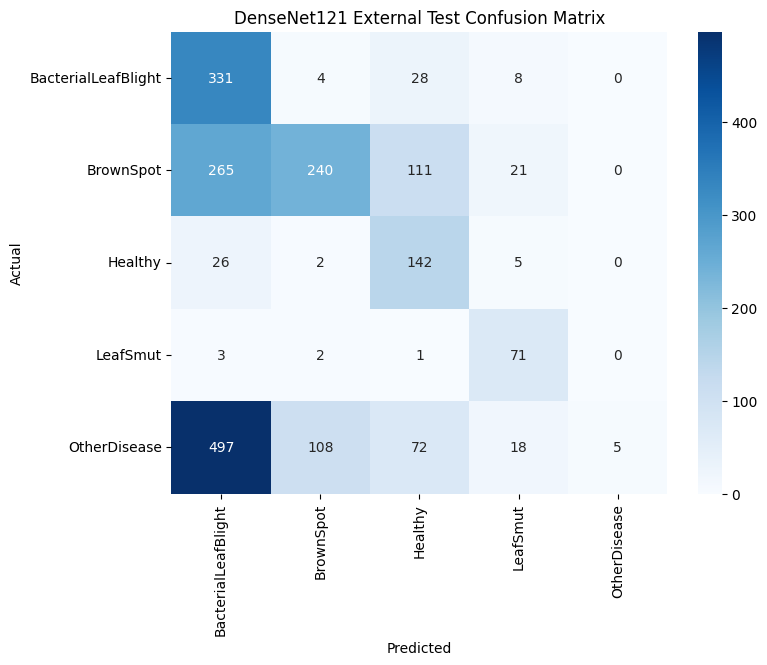

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_preds,
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet121 External Test Confusion Matrix")

plt.show()